# Sharpening a 100 m thermal image with a random forest

*How `lst_rf` in `gee_animation` turns Landsat's 100 m surface temperature into a 20 m field, why the forest is trained per frame on the workstation, what the mean-conserving residual does, and what the method can and cannot deliver.*

This notebook uses **one real frame**: Tegeler Forst Revier 12, July 2024, exported by Earth Engine exactly as the pipeline does (`docs/notebooks/data/`). Everything below runs offline in a minute; the last section shows how to fetch another month.

## 1. The problem: a thermal band that is coarser than everything else

Landsat 8/9 measure surface temperature with a thermal sensor whose pixels are **100 m** wide. The reflectance bands are 30 m, and Sentinel-2 sees the same forest at **10–20 m**. A 100 m thermal pixel over a forest district mixes canopy, clearings, roads and water into one number, so structures you can see in NDVI are invisible in temperature.

**Thermal sharpening** (also called *disaggregation* or *downscaling*) borrows the spatial detail from the fine-resolution bands. The idea rests on one physical assumption: at a given moment, surface temperature is a fairly smooth **function of what the surface is made of** — vegetation cover, built-up fraction, water, and terrain. If we can learn that function at the coarse scale, where we have both the temperature and the predictors, we can evaluate it at the fine scale, where we only have the predictors.

The classic version is **TsHARP / DisTrad** (Kustas 2003, Agam 2007): a straight line `LST = a·NDVI + b`. The random-forest version, "Method 2" in the sharpening literature, replaces the line with a non-linear model of several predictors. That is all `lst_rf` is.

## 2. The ingredients

| ingredient | what | resolution in the export |
|---|---|---|
| target `LST` | Landsat C2 L2 surface temperature, monthly median, °C | 100 m native, delivered on a 20 m grid |
| `ndvi` | (NIR − red)/(NIR + red), Sentinel-2 median of the frame's month ± 30 days | 10 m → 20 m |
| `nirv` | NDVI × NIR, a proxy for photosynthetic canopy that saturates later than NDVI | 10 m → 20 m |
| `ndbi` | (SWIR1 − NIR)/(SWIR1 + NIR), built-up index | 20 m |
| `mndwi` | (green − SWIR1)/(green + SWIR1), open water | 20 m |
| `dem` | Copernicus GLO-30 elevation | 30 m → 20 m |

Two consequences follow. Because NDBI and MNDWI need the 20 m short-wave infrared band, the **honest output resolution is 20 m, not 10 m**. And because Landsat's thermal pixel is 100 m, one coarse cell covers exactly **5 × 5 = 25** fine cells: this factor of 5 is the whole geometry of the method.

In [1]:
import numpy as np, rasterio, matplotlib.pyplot as plt
from pathlib import Path
import sys; sys.path.insert(0, str(Path.cwd().parents[1]))     # repo root, when run from docs/notebooks
from gee_animation.sharpen_local import read_geotiff, block_mean, fit_forest, sharpen_frame, FACTOR
from gee_animation.sharpen import PREDICTORS

DATA = Path("data") if Path("data").exists() else Path("docs/notebooks/data")
lst, bounds, crs, res = read_geotiff((DATA / "r12_2024-07_lst.tif").read_bytes())
pred, _, _, _ = read_geotiff((DATA / "r12_2024-07_predictors.tif").read_bytes())
lst = lst[0]; h, w = lst.shape; pred = pred[:, :h, :w]
print(f"LST {lst.shape} at {res:.0f} m in {crs}; predictors {pred.shape} = {PREDICTORS}")
print(f"coarse/fine factor = {FACTOR}  →  each 100 m cell holds {FACTOR**2} fine cells")
print(f"valid LST cells: {np.isfinite(lst).mean():.0%}; LST range {np.nanmin(lst):.1f}–{np.nanmax(lst):.1f} °C")

LST (549, 552) at 20 m in EPSG:32633; predictors (5, 549, 552) = ('ndvi', 'nirv', 'ndbi', 'mndwi', 'dem')
coarse/fine factor = 5  →  each 100 m cell holds 25 fine cells
valid LST cells: 99%; LST range 19.9–54.2 °C


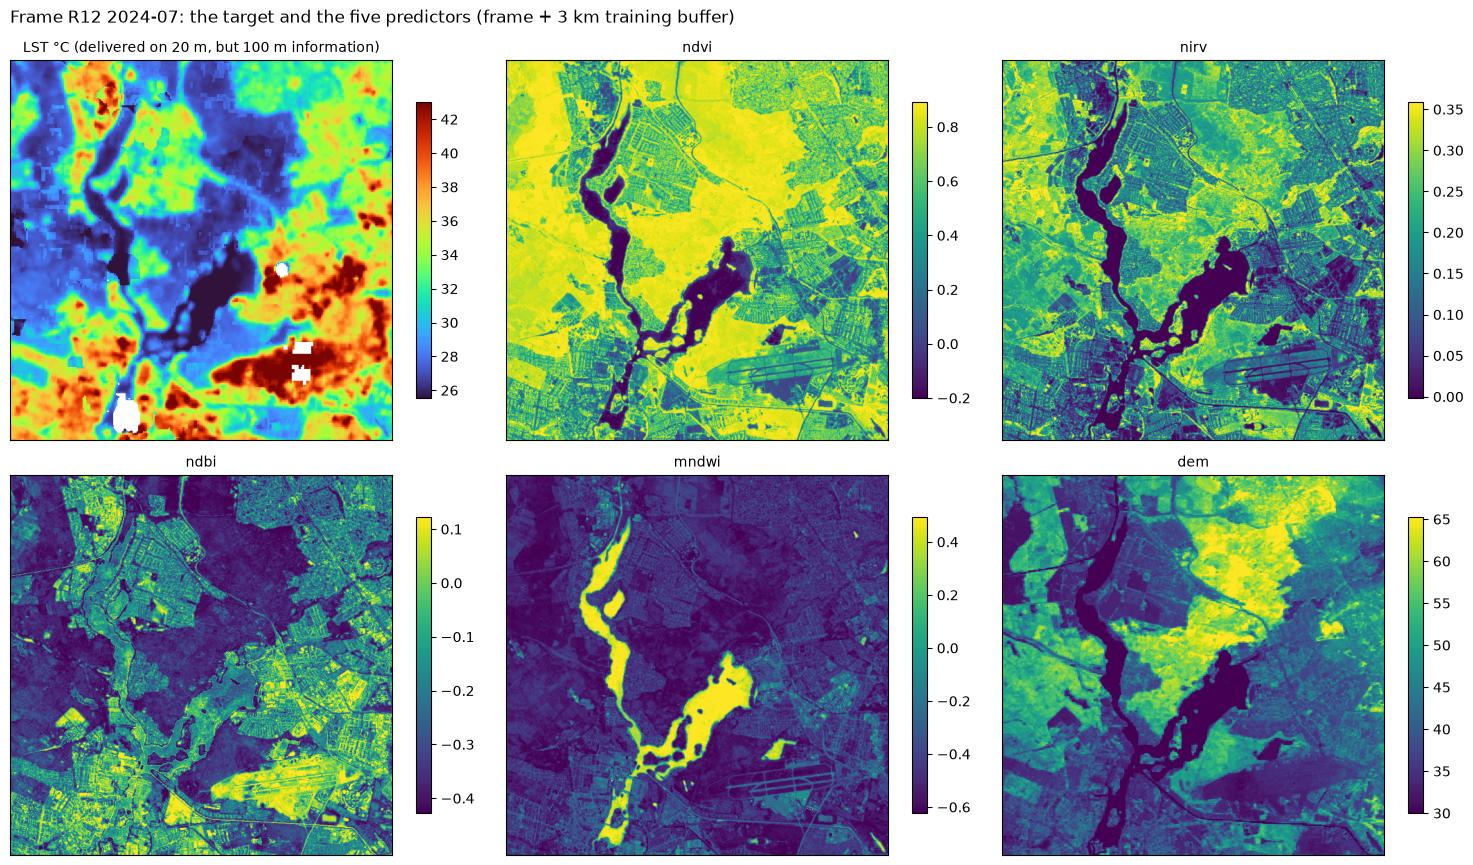

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, a, cmap) in zip(axes.ravel(), [("LST °C (delivered on 20 m, but 100 m information)", lst, "turbo")] + [(n, pred[i], "viridis") for i, n in enumerate(PREDICTORS)]):
    im = ax.imshow(a, cmap=cmap, vmin=np.nanpercentile(a, 2), vmax=np.nanpercentile(a, 98)); ax.set_title(name, fontsize=10); ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle("Frame R12 2024-07: the target and the five predictors (frame + 3 km training buffer)", x=0.01, ha="left"); plt.tight_layout()

Look at the top-left panel: the temperature already sits on a 20 m grid, but it is **blocky at 100 m**, because Earth Engine resampled the thermal band without adding information. The predictors have real 20 m texture.

## 3. Step 1: bring the predictors to the coarse scale

We can only learn the relation where we have both sides. So the predictors are averaged into the same 100 m blocks as the thermal cells. `block_mean` is a NaN-aware mean of every 5 × 5 block.

coarse grid (109, 110); training cells with LST and all predictors: 11,916 of 11,990


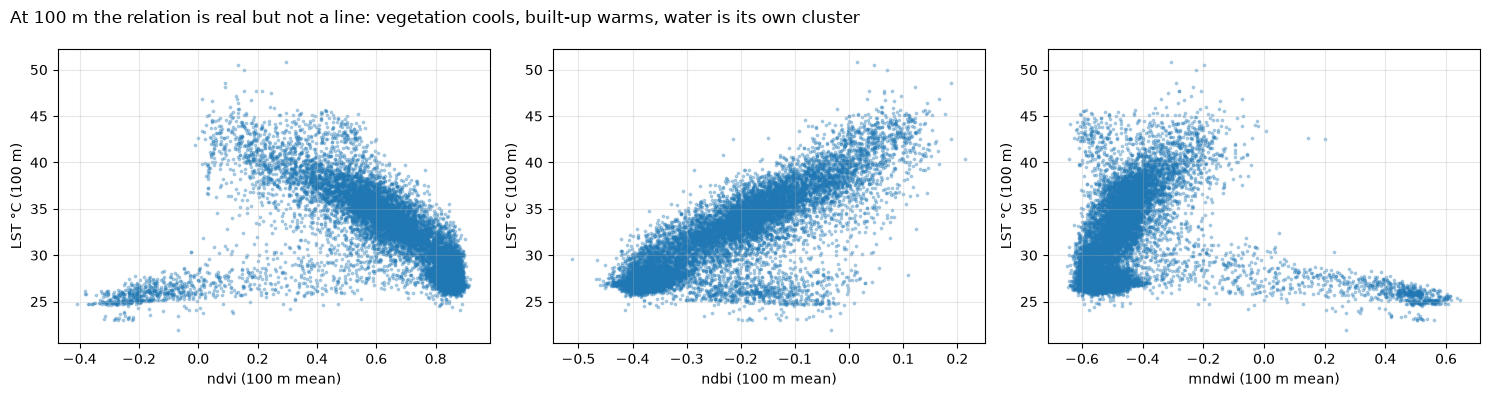

In [3]:
lst_c = block_mean(lst[None], FACTOR)[0]          # (H/5, W/5)
pred_c = block_mean(pred, FACTOR)                  # (5, H/5, W/5)
ok = np.isfinite(lst_c) & np.all(np.isfinite(pred_c), axis=0)
X, y = pred_c[:, ok].T, lst_c[ok]
print(f"coarse grid {lst_c.shape}; training cells with LST and all predictors: {ok.sum():,} of {ok.size:,}")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (xn, xi) in zip(axes, [("ndvi", 0), ("ndbi", 2), ("mndwi", 3)]):
    ax.scatter(X[:, xi], y, s=3, alpha=0.3); ax.set_xlabel(f"{xn} (100 m mean)"); ax.set_ylabel("LST °C (100 m)"); ax.grid(alpha=.3)
plt.suptitle("At 100 m the relation is real but not a line: vegetation cools, built-up warms, water is its own cluster", x=0.01, ha="left"); plt.tight_layout()

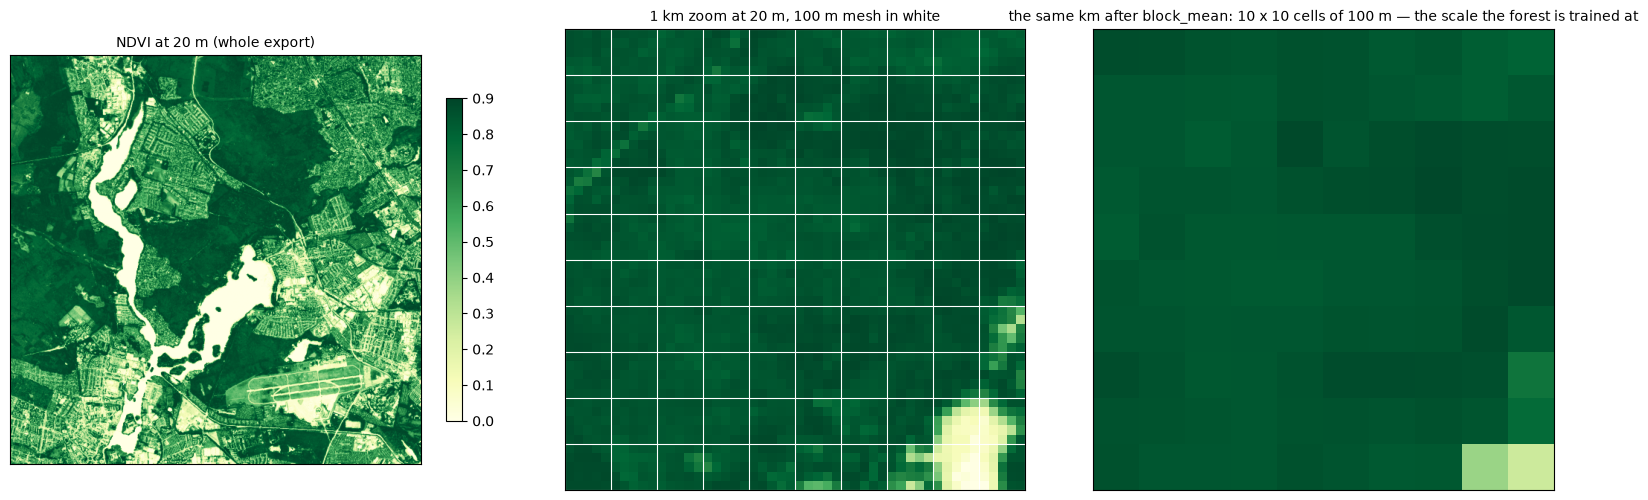

In [4]:
# What aggregation does: the 20 m NDVI next to its 100 m block mean, with the 100 m mesh drawn on a 1 km zoom
zoom = (slice(h//2-25, h//2+25), slice(w//2-25, w//2+25))          # 50 x 50 fine cells = 1 km x 1 km, aligned to the 5 x 5 blocks
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im = axes[0].imshow(pred[0], cmap="YlGn", vmin=0, vmax=0.9); axes[0].set_title("NDVI at 20 m (whole export)", fontsize=10); plt.colorbar(im, ax=axes[0], shrink=0.7)
im = axes[1].imshow(pred[0][zoom], cmap="YlGn", vmin=0, vmax=0.9, interpolation="nearest"); axes[1].set_title("1 km zoom at 20 m, 100 m mesh in white", fontsize=10)
for k in range(0, 51, 5): axes[1].axhline(k - 0.5, color="w", lw=0.8); axes[1].axvline(k - 0.5, color="w", lw=0.8)
cz = (slice((h//2-25)//5, (h//2+25)//5), slice((w//2-25)//5, (w//2+25)//5))
im = axes[2].imshow(pred_c[0][cz], cmap="YlGn", vmin=0, vmax=0.9, interpolation="nearest"); axes[2].set_title("the same km after block_mean: 10 x 10 cells of 100 m — the scale the forest is trained at", fontsize=10)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

This scatter is the whole justification for a **forest instead of a line**. NDVI alone explains a lot, but the water cluster (MNDWI high) and the built-up tail (NDBI high) sit off any single straight line, and the relations interact: a bright, low-NDVI surface is hot if it is a car park and cold if it is a lake.

## 4. Step 2: fit one random forest on this frame's coarse cells

A random forest is an ensemble of decision trees. Each tree is fitted on a bootstrap sample of the training cells and splits the predictor space into boxes with a constant temperature each; the forest's prediction is the average over the trees. Three properties make it a good fit here:

- it captures **non-linear and interacting** relations without us specifying them;
- it **cannot extrapolate** beyond the temperatures it has seen, which is a safety feature for a physical quantity;
- with **out-of-bag** scoring it gives a free honest accuracy estimate: every tree is scored on the cells it did not see.

`fit_forest` uses 100 trees, at least 5 cells per leaf, 70 % of the cells per tree, and at most 5,000 training cells (subsampled) per frame.

In [5]:
model = fit_forest([(lst, pred)])
# fit_forest subsamples at most 5,000 coarse cells with a fixed seed; rebuild that subsample so the OOB predictions line up with their truths
idx = np.random.default_rng(1).choice(len(y), size=min(5000, len(y)), replace=False) if len(y) > 5000 else np.arange(len(y))
oob_rmse = np.sqrt(np.mean((model.oob_prediction_ - y[idx]) ** 2))
print(f"trained on {len(idx):,} of {len(y):,} coarse cells · OOB R² = {model.oob_score_:.2f} · OOB RMSE = {oob_rmse:.2f} K (sd of LST at 100 m: {np.std(y):.2f} K)")
imp = sorted(zip(model.feature_importances_, PREDICTORS), reverse=True)
print("feature importance:", ", ".join(f"{n} {v:.2f}" for v, n in imp))

trained on 5,000 of 11,916 coarse cells · OOB R² = 0.86 · OOB RMSE = 1.75 K (sd of LST at 100 m: 4.73 K)
feature importance: ndbi 0.68, mndwi 0.23, dem 0.03, ndvi 0.03, nirv 0.03


the first three levels of tree #0 (of 100). Each line is a threshold on a predictor; a leaf ends in a temperature:
|--- ndbi <= -0.23
|   |--- ndbi <= -0.32
|   |   |--- dem <= 50.27
|   |   |   |--- ndbi <= -0.38
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- ndbi >  -0.38
|   |   |   |   |--- truncated branch of depth 10
|   |   |--- dem >  50.27
|   |   |   |--- dem <= 56.31
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- dem >  56.31
|   |   |   |   |--- truncated branch of depth 12
|   |--- ndbi >  -0.32
|   |   |--- ndvi <= 0.57
|   |   |   |--- ndvi <= 0.20
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- ndvi >  0.20
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- ndvi >  0.57
|   |   |   |--- ndvi <= 0.77
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- ndvi >  0.77
|   |   |   |   |--- truncated branch of depth 9
|--- ndbi >  -0.23
|   |--- mndwi <= -0.02
|   |   |--- ndbi <= -0.08
|   |   

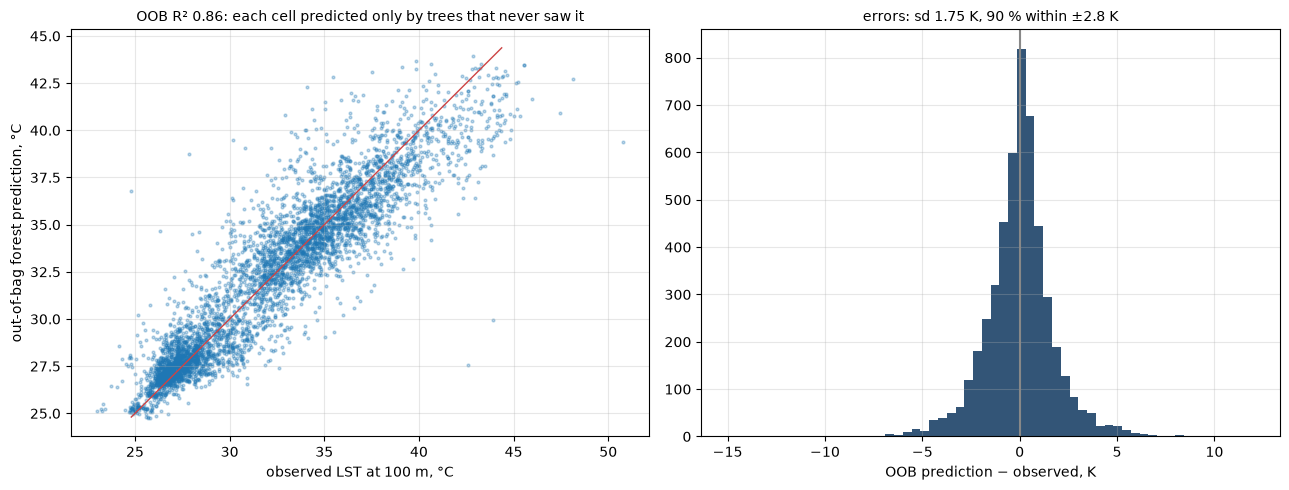

In [6]:
# What the forest learned: out-of-bag prediction against truth, and the first splits of one of its trees
from sklearn.tree import export_text
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y[idx], model.oob_prediction_, s=4, alpha=0.3); lo_, hi_ = np.percentile(y[idx], [0.5, 99.5]); axes[0].plot([lo_, hi_], [lo_, hi_], color="#c44", lw=1)
axes[0].set_xlabel("observed LST at 100 m, °C"); axes[0].set_ylabel("out-of-bag forest prediction, °C"); axes[0].set_title(f"OOB R² {model.oob_score_:.2f}: each cell predicted only by trees that never saw it", fontsize=10); axes[0].grid(alpha=.3)
res_ = model.oob_prediction_ - y[idx]; axes[1].hist(res_, bins=60, color="#357"); axes[1].axvline(0, color="#888"); axes[1].set_xlabel("OOB prediction − observed, K"); axes[1].set_title(f"errors: sd {np.std(res_):.2f} K, 90 % within ±{np.percentile(np.abs(res_), 90):.1f} K", fontsize=10); axes[1].grid(alpha=.3)
plt.tight_layout()
print("the first three levels of tree #0 (of 100). Each line is a threshold on a predictor; a leaf ends in a temperature:")
print(export_text(model.estimators_[0], feature_names=list(PREDICTORS), max_depth=3, decimals=2))

Read the importances with care: they say which predictor the trees *used*, not which one *causes* the temperature. In Tegel the built-up index and NDVI dominate; the DEM is nearly useless because the district has 40 m of relief, and it is kept only so that the same method works on hilly sites.

## 5. Step 3: predict at 20 m, then make the result honest

Applying the forest to the 20 m predictor stack gives a 20 m temperature field. But this field is only *what the forest thinks a pixel with these indices should be*; it does not know what Landsat actually measured in that particular cell on that particular day. The fix is the **residual correction**, and it is the most important line of the method:

1. aggregate the fine prediction back to 100 m (mean of each 5 × 5 block);
2. residual = observed coarse LST − aggregated prediction;
3. add that residual to every fine cell of the block.

After this, **every 100 m cell of the sharpened field averages exactly to the observed temperature**. The forest contributes only the *within-cell pattern*; the *level* stays Landsat's. Without this step the output would be a texture map wearing temperature units.

max |mean of 25 sharpened cells − observed 100 m LST| = 9.54e-06 K  (conservation holds to float precision)
residual field: sd 1.74 K, range -11.8 … +14.0 K — what the forest could NOT explain on this day


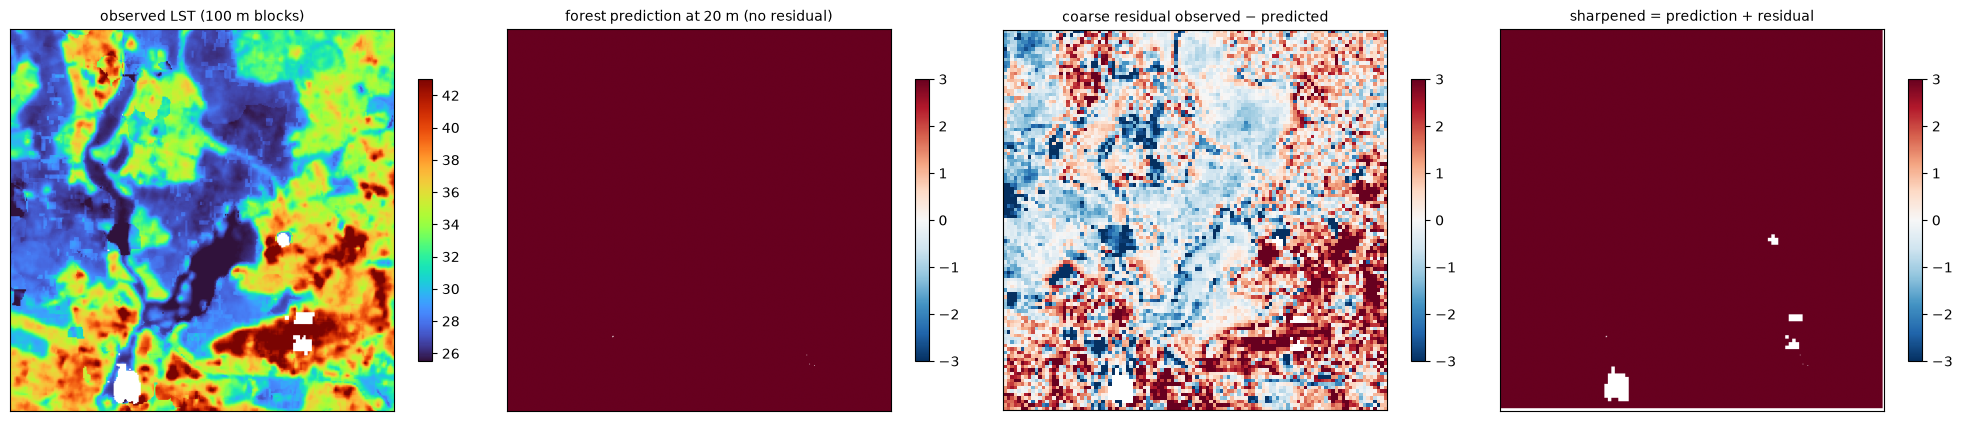

In [7]:
sharp = sharpen_frame(lst, pred, model)
fit_f = np.full_like(sharp, np.nan); okf = np.all(np.isfinite(pred), axis=0); fit_f[okf] = model.predict(pred[:, okf].T)   # the raw forest prediction, before the residual
back = block_mean(sharp[None], FACTOR)[0]
err = np.abs(back - lst_c); print(f"max |mean of 25 sharpened cells − observed 100 m LST| = {np.nanmax(err):.2e} K  (conservation holds to float precision)")
resid_c = lst_c - block_mean(fit_f[None], FACTOR)[0]
print(f"residual field: sd {np.nanstd(resid_c):.2f} K, range {np.nanmin(resid_c):+.1f} … {np.nanmax(resid_c):+.1f} K — what the forest could NOT explain on this day")
fig, axes = plt.subplots(1, 4, figsize=(20, 5)); vmin, vmax = np.nanpercentile(lst, 2), np.nanpercentile(lst, 98)
for ax, (t, a) in zip(axes, [("observed LST (100 m blocks)", lst), ("forest prediction at 20 m (no residual)", fit_f), ("coarse residual observed − predicted", resid_c), ("sharpened = prediction + residual", sharp)]):
    im = ax.imshow(a, cmap="turbo" if "residual" not in t else "RdBu_r", vmin=vmin if "residual" not in t else -3, vmax=vmax if "residual" not in t else 3); ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()

### Inside one coarse cell

The clearest way to see the residual correction is to follow **one 100 m cell** through the three steps: the 25 forest predictions, their mean against the observed value, and the corrected 25 values. Then a 1 km transect through the district shows how the sharpened field follows the observed steps while adding structure between them.

coarse cell (54,55): observed Landsat LST = 26.35 °C
  25 forest predictions: mean 27.23 °C, min 26.59, max 28.35  →  residual = observed − mean = -0.88 K
  after adding the residual to all 25: mean 26.35 °C (= observed), min 25.71, max 27.47; the within-cell pattern is unchanged


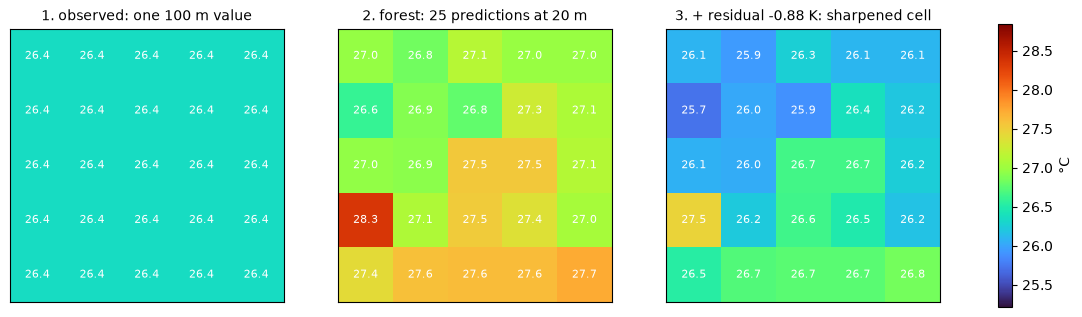

In [8]:
# pick a coarse cell in the middle of the export with full data, and expand it
ci, cj = lst_c.shape[0] // 2, lst_c.shape[1] // 2
while not (np.isfinite(lst_c[ci, cj]) and np.all(np.isfinite(fit_f[ci*5:ci*5+5, cj*5:cj*5+5]))): cj += 1
blk_fit = fit_f[ci*5:ci*5+5, cj*5:cj*5+5]; blk_sharp = sharp[ci*5:ci*5+5, cj*5:cj*5+5]; obs = lst_c[ci, cj]; r = obs - blk_fit.mean()
print(f"coarse cell ({ci},{cj}): observed Landsat LST = {obs:.2f} °C")
print(f"  25 forest predictions: mean {blk_fit.mean():.2f} °C, min {blk_fit.min():.2f}, max {blk_fit.max():.2f}  →  residual = observed − mean = {r:+.2f} K")
print(f"  after adding the residual to all 25: mean {blk_sharp.mean():.2f} °C (= observed), min {blk_sharp.min():.2f}, max {blk_sharp.max():.2f}; the within-cell pattern is unchanged")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6)); v0, v1 = min(blk_fit.min(), blk_sharp.min()) - 0.5, max(blk_fit.max(), blk_sharp.max()) + 0.5
for ax, (t, a) in zip(axes, [("1. observed: one 100 m value", np.full((5, 5), obs)), ("2. forest: 25 predictions at 20 m", blk_fit), (f"3. + residual {r:+.2f} K: sharpened cell", blk_sharp)]):
    im = ax.imshow(a, cmap="turbo", vmin=v0, vmax=v1, interpolation="nearest"); ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    for (yy, xx), val in np.ndenumerate(a): ax.text(xx, yy, f"{val:.1f}", ha="center", va="center", fontsize=8, color="w")
plt.colorbar(im, ax=axes, shrink=0.8, label="°C")

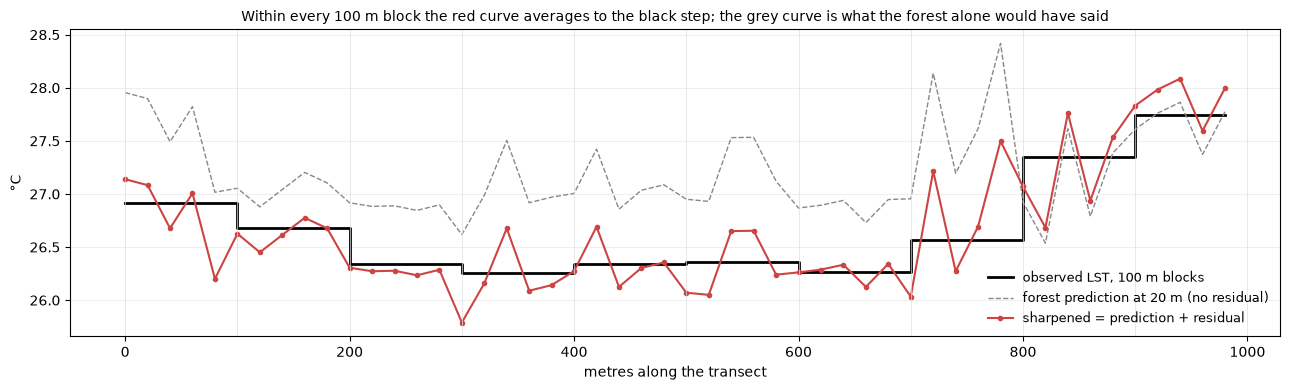

In [9]:
# a 1 km east–west transect: observed 100 m steps vs the sharpened 20 m field
row = ci * 5 + 2; cols = slice(cj*5 - 25, cj*5 + 25); xm = np.arange(50) * 20
fig, ax = plt.subplots(figsize=(13, 4))
ax.step(xm, np.repeat(lst_c[ci, (cj*5-25)//5:(cj*5+25)//5], 5), where="post", color="k", lw=2, label="observed LST, 100 m blocks")
ax.plot(xm, fit_f[row, cols], color="#888", lw=1, ls="--", label="forest prediction at 20 m (no residual)")
ax.plot(xm, sharp[row, cols], color="#c44", lw=1.5, marker="o", ms=3, label="sharpened = prediction + residual")
for k in range(0, 1001, 100): ax.axvline(k, color="#ddd", lw=0.5)
ax.set_xlabel("metres along the transect"); ax.set_ylabel("°C"); ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.2, axis="y")
ax.set_title("Within every 100 m block the red curve averages to the black step; the grey curve is what the forest alone would have said", fontsize=10)
plt.tight_layout()

## 6. Why one forest per frame, not one per month across years

The first design pooled all Julys of ten years into one forest per calendar month, with the appealing promise of a model you could reuse. The rendered animation "looked like overfitted noise, in the end not even the street was visible". The measurement explained why: the pooled July field had a **high-frequency noise of 1.8 K** against 0.6 K for a forest trained on that month alone, and the two fields correlated at only 0.41.

The reason is physical, not statistical. The index → temperature relation **does not transfer between dates**: each pass has its own sun angle, wind, soil moisture and phenology. A forest asked to serve ten Julys answers every 20 m pixel with a compromise that flips between leaves, and the flips show up as speckle. So `sharpen_local` trains **one forest per frame** on that frame's own 100 m cells and scores it out-of-bag. Models are saved with `joblib` under `out/models/<run name>/<label>.joblib`, which is also how you would inspect one later.

We cannot reproduce the ten-year experiment from one frame, but we can show the **mechanism**. A forest is piecewise constant: each tree answers with the mean of a leaf, and a leaf boundary is a hard threshold on a predictor. Shift the predictors by a small amount, as a different date does, and many pixels fall into a neighbouring leaf, so the prediction jumps. Apply this frame's own forest to the same predictors nudged by +0.02 NDVI and −0.02 NDBI, a change far smaller than the difference between two Julys, and look at the difference map.

the same forest on slightly nudged predictors: mean change -0.47 K, but pixel-to-pixel scatter (sd) 0.58 K and high-frequency noise 0.48 K
for comparison, the high-frequency noise of the sharpened field itself over this frame (city included) is 1.52 K


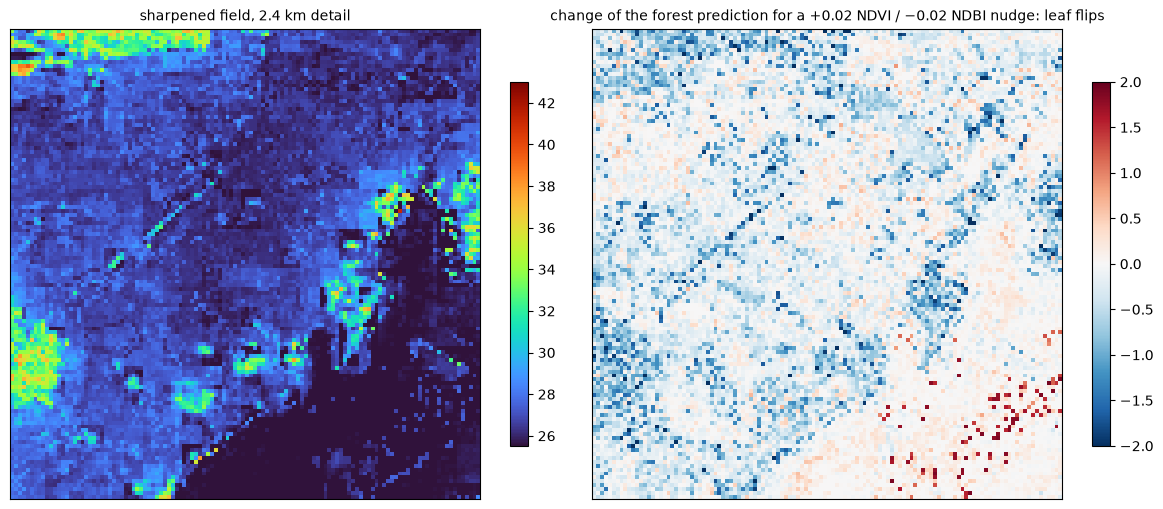

In [10]:
def hf_noise(a):
    from scipy.ndimage import median_filter
    m = median_filter(np.nan_to_num(a, nan=np.nanmean(a)), size=3); return float(np.nanstd(a - m))
pred_nudged = pred.copy(); pred_nudged[0] += 0.02; pred_nudged[2] -= 0.02
fit_nudged = np.full_like(fit_f, np.nan); fit_nudged[okf] = model.predict(pred_nudged[:, okf].T)
diff = fit_nudged - fit_f
print(f"the same forest on slightly nudged predictors: mean change {np.nanmean(diff):+.2f} K, but pixel-to-pixel scatter (sd) {np.nanstd(diff):.2f} K and high-frequency noise {hf_noise(diff):.2f} K")
print(f"for comparison, the high-frequency noise of the sharpened field itself over this frame (city included) is {hf_noise(sharp):.2f} K")
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5)); sl = (slice(h//2-60, h//2+60), slice(w//2-60, w//2+60))
im = axes[0].imshow(sharp[sl], cmap="turbo", vmin=vmin, vmax=vmax); axes[0].set_title("sharpened field, 2.4 km detail", fontsize=10); plt.colorbar(im, ax=axes[0], shrink=0.7)
im = axes[1].imshow(diff[sl], cmap="RdBu_r", vmin=-2, vmax=2); axes[1].set_title("change of the forest prediction for a +0.02 NDVI / −0.02 NDBI nudge: leaf flips", fontsize=10); plt.colorbar(im, ax=axes[1], shrink=0.7)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

The response to a tiny, spatially uniform nudge is **not** uniform: it is a speckle of jumps wherever a pixel crosses a leaf boundary. A forest trained on another date sees every pixel through such shifted boundaries, and the speckle becomes the noise that spoiled the pooled animation. Training on the frame's own coarse cells puts the boundaries where this day's data put them.

## 7. What the sharpening can and cannot deliver: the degrade-and-recover test

There is no 20 m thermal truth to compare against. The standard trick is to **degrade real data and try to recover it**: aggregate the real 100 m temperature to 300 m, sharpen it back to 100 m with the method under test, and compare with the real 100 m field. The ratio of scales (3) is close to the production ratio (5), and the answer is a number.

The pre-registered gate for `lst_rf` was: beat the linear TsHARP by 0.2 K in six of eight months and never lose to "no sharpening at all". **It failed.** The forest beat the line in three months and lost to doing nothing in five. The cause is measurable and instructive:

In [11]:
lst_300 = block_mean(lst_c[None], 3)[0]     # degrade the real 100 m field to 300 m
print(f"sd of the temperature field: at 100 m {np.nanstd(lst_c):.2f} K, at 300 m {np.nanstd(lst_300):.2f} K")
for i, n in enumerate(PREDICTORS):
    p100 = pred_c[i][ok]; p300 = block_mean(pred_c[i][None], 3)[0]; l300 = lst_300; m = np.isfinite(p300) & np.isfinite(l300)
    print(f"  corr(LST, {n:5s}): 100 m {np.corrcoef(p100, y)[0,1]:+.2f}   300 m {np.corrcoef(p300[m], l300[m])[0,1]:+.2f}")

sd of the temperature field: at 100 m 4.73 K, at 300 m 4.55 K
  corr(LST, ndvi ): 100 m -0.34   300 m -0.38
  corr(LST, nirv ): 100 m -0.46   300 m -0.51
  corr(LST, ndbi ): 100 m +0.79   300 m +0.85
  corr(LST, mndwi): 100 m -0.08   300 m -0.08
  corr(LST, dem  ): 100 m -0.43   300 m -0.46


The temperature field has **almost the same variance at 100 m as at 300 m**, and the predictors correlate with it equally at both scales. In other words the Landsat thermal product carries very little structure below about 300 m, so there is little to recover, and a model fitted at 300 m has nothing extra to say at 100 m. Any detail a sharpener adds at that scale is scored against a field that does not contain it.

The honest conclusion, which the pipeline adopts:

- the 20 m detail is **index texture carrying the observed coarse temperature**, a visualisation rather than a measurement;
- what *is* quantitatively usable is the **within-frame contrast**, because the residual correction guarantees the levels and the forest only redistributes them: that is why the windthrow analyses compare windthrow cells with canopy cells inside one frame, and why the renders use `region_only: true` and `relative: region_mean` (each frame minus its own footprint mean, in kelvin).

## 8. Where this lives in the pipeline

```
config: index: lst_rf, sharpen: local
  → Earth Engine: monthly Landsat LST composite + Sentinel-2/DEM predictor stack, both exported as 20 m GeoTIFFs over the frame + 3 km buffer (cached)
  → sharpen_local.train_frame_models: one forest per frame, OOB score → <out>/<name>_models.csv, joblib under <out>/models/<name>/
  → sharpen_local.sharpen_frame: predict at 20 m + mean-conserving residual → LocalImage
  → focus (region_only / relative) → render (frames, MP4, GIF)
```

The functions used in this notebook are the pipeline's own (`gee_animation/sharpen_local.py`); nothing was re-implemented here. To try another month, run the pipeline with `geotiffs: true`, or export the two inputs directly:

```python
# needs earthengine auth; mirrors sharpen_local.apply for one frame
import dataclasses, urllib.request, ee
from gee_animation import auth, aoi, collection, compositing, sharpen
from gee_animation.config import RunConfig
from gee_animation.products import INDEX_BAND
cfg = dataclasses.replace(RunConfig.from_yaml("config/r12_zoom_lst_rf_local_10yr.yaml"), start="2023-08-01", end="2023-09-01", pool_years=None, pool_strategy=None)
auth.init(cfg.project); fg = aoi.parse(cfg.frame_aoi); rg = aoi.parse(cfg.region_aoi)
frame = compositing.composite(collection.build(cfg, fg, rg), cfg)[0]
geom = fg.buffer(sharpen.TRAIN_BUFFER_M).bounds(); params = dict(region=geom, crs="EPSG:32633", scale=sharpen.FINE_M, format="GEO_TIFF", filePerBand=False)
lst_bytes = urllib.request.urlopen(frame.image.select(INDEX_BAND).unmask(-9999).getDownloadURL(params)).read()
pred_bytes = urllib.request.urlopen(sharpen.s2_predictors(ee.Date(frame.image.get("s2_start")), ee.Date(frame.image.get("s2_end")), geom).unmask(-9999).getDownloadURL(params)).read()
```

## 9. Further reading

- Kustas, W. P. et al. (2003): *Estimating subpixel surface temperatures and energy fluxes from the vegetation index–radiometric temperature relationship*, Remote Sensing of Environment 85. The DisTrad idea.
- Agam, N. et al. (2007): *A vegetation index based technique for spatial sharpening of thermal imagery*, Remote Sensing of Environment 107. TsHARP.
- Gao, F., Kustas, W. P., Anderson, M. C. (2012): *A data mining approach for sharpening thermal satellite imagery over land*, Remote Sensing 4. The regression-tree ancestor of "Method 2".
- Breiman, L. (2001): *Random forests*, Machine Learning 45. Out-of-bag scoring is section 3.